<img src="banner.png" width="100%" style="max-height:300px; object-fit:cover;"/>

# Curso de Agentes de IA con LangGraph

Este notebook sirve como una guía introductoria para el diseño e implementación de **Agentes de Inteligencia Artificial** utilizando el framework **LangChain** y la integración de la familia **Gemini** a través de **Google Cloud Vertex AI**.

A lo largo de este curso, aprenderemos a:

- Conectar modelos de lenguaje con herramientas externas.
- Crear flujos de trabajo cíclicos basados en grafos.
- Dotar a los sistemas de capacidades de razonamiento.
- Diseñar agentes con toma de decisiones autónoma.

> El objetivo es construir una base sólida para desarrollar agentes inteligentes capaces de interactuar con herramientas, procesar información y ejecutar tareas de forma dinámica.


## Paso 1: Instalación de Dependencias

Para comenzar, instalaremos todas las librerías necesarias para el curso en su versión más reciente. Esto incluye:

- **langchain**, **langchain-community**, **langchain-google-genai**: módulos principales y de integración con Google Generative AI (Gemini).
- **langgraph**: motor para crear agentes basados en grafos con estados y ciclos.
- **python-dotenv**: carga de variables de entorno desde un archivo `.env`.
- **arxiv**: herramienta de búsqueda y consulta académica para ejercicios del curso.

> **Nota:** usamos el parámetro `-q` (*quiet*) para realizar una instalación limpia y libre de barras de progreso ruidosas.


In [1]:
# Instalar dependencias del curso de forma silenciosa
!pip install -q -U langchain langchain-community langgraph langchain-google-genai langchain-tavily google-auth python-dotenv arxiv tavily-python

## Paso 2: Autenticación con Google Cloud (ADC)

Para conectarnos a **Vertex AI** sin usar una API key, utilizamos **Application Default Credentials (ADC)**. Este mecanismo detecta automáticamente las credenciales del entorno local.

Ejecuta los siguientes comandos **una sola vez** desde la terminal integrada de DataSpell (`Alt + F12`):

```bash
# Iniciar sesión con tu cuenta de Google
gcloud auth login

# Generar el archivo de credenciales ADC en tu entorno local
gcloud auth application-default login

# Establecer tu proyecto de Google Cloud (debe tener Vertex AI habilitado)
gcloud config set project TU_PROJECT_ID
```

Las credenciales se almacenan en `%APPDATA%\gcloud\application_default_credentials.json` y son detectadas automáticamente por el SDK.

> **Nota:** el `project_id` se carga desde un archivo `.env` para no hardcodearlo en el código.


## Paso 3: Configuración del Entorno e Importación de Librerías

En este paso, configuraremos el entorno de Python e importaremos las librerías esenciales para trabajar con **LangChain** y **LangGraph**.

Esto incluye:

- **warnings**: módulo utilizado para controlar y filtrar advertencias durante la ejecución del notebook.
- **dotenv**: carga del `GOOGLE_CLOUD_PROJECT` y `TAVILY_API_KEY` desde el archivo `.env`.
- **google.auth**: obtención de credenciales ADC para autenticación con Google Cloud sin API key.
- **langchain-google-genai**: integración de LangChain con los modelos Gemini de Google.
- **LangGraph**: extensión que permite crear flujos de trabajo basados en grafos, estados y ciclos.

> **Nota:** configuraremos un filtro de advertencias para mantener la salida del notebook limpia, evitando mensajes de depreciación o avisos menores que no afecten el desarrollo del curso.


In [2]:
import os
import warnings
from dotenv import load_dotenv

load_dotenv()

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["PYTHONWARNINGS"] = "ignore"

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
import langgraph

print("✅ Entorno configurado e importaciones listas.")

✅ Entorno configurado e importaciones listas.


## Paso 4: Inicialización del Modelo, Herramientas y Prueba de Conexión

En este paso, inicializaremos el modelo **Gemini 2.5 Flash**, definiremos las herramientas del agente y realizaremos una prueba de conexión.

Esto incluye:

- **Inicialización del modelo**: creación de una instancia de `ChatGoogleGenerativeAI` autenticada mediante ADC con Vertex AI.
- **busca_web**: herramienta que realiza búsquedas en la web usando Tavily Search.
- **create_react_agent**: creación del agente con `system_prompt` y herramientas vinculadas.
- **Prueba de conexión**: verificación de que las credenciales ADC y la configuración del entorno están funcionando.

> **Nota:** esta prueba permite confirmar que el entorno está listo para comenzar a trabajar con modelos de lenguaje dentro de flujos creados con LangChain y LangGraph.


In [3]:
import google.auth
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import create_react_agent

# Obtener credenciales ADC y project_id
credentials, project_id = google.auth.default()

# Inicializar el modelo Gemini 2.5 Flash con credenciales ADC
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    credentials=credentials
)

@tool
def busca_web(query: str) -> list:
    """Realiza una búsqueda en la web sobre un tema específico"""
    tavily_search = TavilySearch(max_results=3)
    return tavily_search.invoke(query)

tools = [busca_web]

system_prompt = """
Actúa como un asistente útil y especializado en investigación.
Utiliza las herramientas proporcionadas para responder a las preguntas del usuario.

Herramientas disponibles:
- busca_web: realiza búsquedas en la web y devuelve enlaces y resúmenes.

Siempre que el usuario pregunte sobre un tema específico:
1. Usa la herramienta busca_web.
2. Analiza los resultados.
3. Devuelve una respuesta clara.
4. Incluye los enlaces de las fuentes utilizadas.
"""

agente_web = create_react_agent(
    model=llm,
    tools=tools,
    prompt=system_prompt
)

print("\n🧰 Herramientas registradas:")
for t in tools:
    print(f"  ✅ {t.name:<15} — {t.description}")
print("\n✅ Agente creado con create_react_agent.")


🧰 Herramientas registradas:
  ✅ busca_web       — Realiza una búsqueda en la web sobre un tema específico

✅ Agente creado con create_react_agent.


## Paso 5: Prueba de Herramientas

En este paso probaremos que las herramientas vinculadas al modelo funcionan correctamente de forma independiente.

Esto incluye:

- **busca_web**: el agente detecta que debe buscar en la web y retorna una respuesta elaborada con fuentes.

> **Nota:** el agente maneja el ciclo razonamiento → herramienta → respuesta de forma autónoma usando el patrón ReAct.


In [4]:
import re, html

def limpiar_texto(texto: str) -> str:
    texto = html.unescape(texto)
    texto = re.sub(r'\[.*?\]\(.*?\)', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Prueba con búsqueda web
resultado = agente_web.invoke({
    "messages": [("user", "¿Cuáles son los impactos de la inteligencia artificial en la educación?")]
})

respuesta_final = resultado["messages"][-1]
c = respuesta_final.content
if isinstance(c, list):
    contenido = ' '.join(p['text'] for p in c if isinstance(p, dict) and 'text' in p)
else:
    contenido = c
print("\n🤖 Respuesta del agente:")
print("─" * 60)
print(limpiar_texto(contenido))


🤖 Respuesta del agente:
────────────────────────────────────────────────────────────
La inteligencia artificial (IA) está transformando el panorama educativo, ofreciendo tanto oportunidades significativas como desafíos importantes. **Impactos Positivos y Oportunidades:** * **Transformación de la enseñanza y el aprendizaje:** La IA está cambiando fundamentalmente cómo los estudiantes adquieren conocimientos, cómo los maestros imparten sus lecciones y cómo las instituciones educativas estructuran sus procesos pedagógicos. * **Mejora de los procesos educativos:** Ofrece un enfoque renovado y una nueva dirección para docentes y estudiantes, mejorando la eficiencia y efectividad de la educación. * **Personalización de la enseñanza:** La IA permite adaptar el aprendizaje a las necesidades individuales de cada estudiante, potenciando experiencias educativas más personalizadas. * **Creación y mejora del sistema educativo:** Facilita la integración de la tecnología en diversos espacios de apre

## Paso 6: Agente Científico con ArXiv

En este paso crearemos un agente especializado en búsqueda de artículos académicos usando **ArXiv**.

- **tool_cientifica**: herramienta que consulta arXiv y retorna títulos, autores y resúmenes.
- **agente_cientifico**: agente ReAct con `create_react_agent` vinculado a la herramienta arXiv.

> **Nota:** ArXiv es un repositorio de acceso abierto con más de 2 millones de artículos científicos en física, matemáticas, computación y más.


In [5]:
import arxiv

@tool
def tool_cientifica(query: str) -> str:
    """Busca artículos científicos en arXiv sobre un tema específico"""
    client = arxiv.Client()
    search = arxiv.Search(query=query, max_results=5)
    resultados = []
    for r in client.results(search):
        resultados.append(f"- {r.title} ({r.published.year})\n  {r.entry_id}")
    return "\n".join(resultados) if resultados else "No se encontraron resultados."

system_prompt2 = """
Actúa como un asistente útil.
Usa las herramientas proporcionadas para responder a las preguntas del usuario.

- tool_cientifica: Retorna resultados de una búsqueda en arXiv.

Cuando el usuario pregunte sobre un tema específico, usa tool_cientifica y devuelve los títulos de los artículos encontrados.
"""

agente_cientifico = create_react_agent(
    model=llm,
    tools=[tool_cientifica],
    prompt=system_prompt2
)

resultado = agente_cientifico.invoke({
    "messages": [
        ("user", "AI impact in education")
    ]
})

contenido = resultado["messages"][-1].content
if isinstance(contenido, list):
    print(contenido[0]["text"])
else:
    print(contenido)

Aquí tienes algunos artículos sobre el impacto de la IA en la educación:

- Need of AI in Modern Education: in the Eyes of Explainable AI (xAI) (2024)
- Exploring utilization of generative AI for research and education in data-driven materials science (2025)
- AI & Data Competencies: Scaffolding holistic AI literacy in Higher Education (2025)


## Paso 7: Agentes Especializados Encapsulados

En este paso encapsulamos los agentes web y científico como funciones reutilizables que operan sobre un estado compartido (`AgentState`).

- **AgentState**: estructura de datos que almacena la consulta del usuario y las respuestas de cada agente.
- **funcion_agente_web**: reutiliza `agente_web` del Paso 4 para realizar búsquedas web con Tavily.
- **funcion_agente_cientifico**: reutiliza `agente_cientifico` del Paso 6 para consultar arXiv.

> **Nota:** al reutilizar los agentes ya inicializados se evita reinstanciar el LLM en cada llamada, lo que mejora significativamente el rendimiento.


In [6]:
from typing import TypedDict, Dict

# ====================== ESTADO DEL AGENTE ======================
class AgentState(TypedDict):
    user_query: str
    web_answer: str
    scientific_answer: str
    final_answer: str
    router_decision: str


# ====================== AGENTE WEB (reutiliza agente_web del Paso 4) ======================
def funcion_agente_web(state: AgentState) -> Dict:
    resultado = agente_web.invoke({"messages": [("user", state["user_query"])]})
    respuesta = resultado["messages"][-1].content
    if isinstance(respuesta, list):
        respuesta = " ".join(p["text"] for p in respuesta if isinstance(p, dict) and "text" in p)
    state["web_answer"] = respuesta
    return state


# ====================== AGENTE CIENTÍFICO (reutiliza agente_cientifico del Paso 6) ======================
def funcion_agente_cientifico(state: AgentState) -> Dict:
    resultado = agente_cientifico.invoke({"messages": [("user", state["user_query"])]})
    respuesta = resultado["messages"][-1].content
    if isinstance(respuesta, list):
        respuesta = " ".join(p["text"] for p in respuesta if isinstance(p, dict) and "text" in p)
    state["scientific_answer"] = respuesta
    return state


print("✅ Paso 7: Agentes especializados encapsulados y listos para usar.")


✅ Paso 7: Agentes especializados encapsulados y listos para usar.


## Paso 7.1: Prueba de Agentes Simultáneos con Salida Formateada

En este paso probaremos ambos agentes funcionando de forma **paralela** sobre la misma consulta del usuario, recolectando y formateando sus respuestas de forma legible.

- **Ejecución concurrente**: usa threading para ejecutar web + científico en paralelo.
- **Salida formateada**: cada respuesta se muestra con encabezados claros y separadores visuales.
- **Agregación**: combina ambas respuestas en una salida final integrada.


In [7]:
import threading

consulta_usuario = "¿Cuál es el impacto de la inteligencia artificial en la educación?"
consulta_en = "What is the impact of artificial intelligence in education?"

state_web = AgentState(user_query=consulta_usuario, web_answer="", scientific_answer="", final_answer="")
state_cien = AgentState(user_query=consulta_en, web_answer="", scientific_answer="", final_answer="")

# Resultados locales para evitar race conditions
resultados = {"web": "", "cientifico": ""}

def ejecutar_web():
    try:
        print("🔍 [WEB] Iniciando búsqueda web...")
        funcion_agente_web(state_web)
        resultados["web"] = state_web["web_answer"]
        print("✅ [WEB] Búsqueda completada\n")
    except Exception as e:
        resultados["web"] = f"❌ Error en agente web: {str(e)}"
        print(f"❌ [WEB] Error: {e}\n")

def ejecutar_cientifico():
    try:
        print("📚 [CIENTÍFICO] Iniciando búsqueda en arXiv...")
        funcion_agente_cientifico(state_cien)
        resultados["cientifico"] = state_cien["scientific_answer"]
        print("✅ [CIENTÍFICO] Búsqueda completada\n")
    except Exception as e:
        resultados["cientifico"] = f"❌ Error en agente científico: {str(e)}"
        print(f"❌ [CIENTÍFICO] Error: {e}\n")

# Ejecutar agentes en paralelo usando threading
print("\n🚀 Ejecutando agentes en paralelo...\n")
print("=" * 70)

thread_web = threading.Thread(target=ejecutar_web)
thread_cientifico = threading.Thread(target=ejecutar_cientifico)

thread_web.start()
thread_cientifico.start()
thread_web.join()
thread_cientifico.join()

print("=" * 70)
print("\n📊 RESULTADOS CONSOLIDADOS\n")

# Mostrar respuesta WEB
print("\n" + "─" * 70)
print("  🌐 RESPUESTA WEB (Tavily)")
print("─" * 70)
print()
respuesta_web = limpiar_texto(resultados['web'])
for i, linea in enumerate(respuesta_web.split('. '), 1):
    if linea.strip():
        print(f"  {i}. {linea.strip()}." if not linea.strip().endswith('.') else f"  {i}. {linea.strip()}")

# Mostrar respuesta CIENTÍFICA
print("\n" + "─" * 70)
print("  📚 RESPUESTA CIENTÍFICA (arXiv)")
print("─" * 70)
print()
respuesta_cientifica = limpiar_texto(resultados['cientifico'])
print(f"  {respuesta_cientifica}")

# Resumen final
print("\n" + "=" * 70)
print("\n✨ ESTADO FINAL DEL AGENTE\n")
print(f"📝 Consulta: {consulta_usuario}")
print(f"🌐 Respuesta Web: {len(resultados['web'])} caracteres")
print(f"📚 Respuesta Científica: {len(resultados['cientifico'])} caracteres")
print("\n" + "=" * 70)


🚀 Ejecutando agentes en paralelo...

🔍 [WEB] Iniciando búsqueda web...
📚 [CIENTÍFICO] Iniciando búsqueda en arXiv...
✅ [WEB] Búsqueda completada

✅ [CIENTÍFICO] Búsqueda completada


📊 RESULTADOS CONSOLIDADOS


──────────────────────────────────────────────────────────────────────
  🌐 RESPUESTA WEB (Tavily)
──────────────────────────────────────────────────────────────────────

  1. La inteligencia artificial (IA) está teniendo un impacto significativo en la educación, presentando tanto oportunidades como desafíos.
  2. **Oportunidades:** * **Personalización del aprendizaje:** La IA puede adaptar la enseñanza a las necesidades individuales de cada estudiante, ofreciendo experiencias de aprendizaje más personalizadas y efectivas.
  3. * **Mejora de procesos cognitivos:** La IA tiene la capacidad de mejorar diversos procesos cognitivos en el aprendizaje.
  4. * **Revolución en la enseñanza y el aprendizaje:** Ofrece un conjunto de oportunidades sin precedentes para transformar la forma 

## Paso 8: Definiendo un grafo para combinar agentes

En este paso conectaremos los agentes especializados en un flujo con **LangGraph** para ejecutar primero la búsqueda web, luego la búsqueda científica y finalmente consolidar ambas respuestas en un solo resultado.

> **Nota:** el nodo `supervisor` toma el estado compartido y arma una respuesta final con los resultados de ambos agentes.

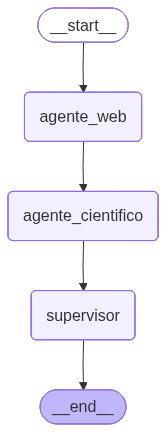

## Resultados combinados de búsqueda

### Resultados desde la Web

La Inteligencia Artificial (IA) está generando un impacto significativo y transformador en la medicina, aunque su aplicación en la práctica clínica aún presenta ciertas limitaciones.

**Impactos Positivos de la IA en la Medicina:**

*   **Optimización y Eficiencia:** La IA optimiza la gestión hospitalaria y la investigación biomédica, contribuyendo a reducir la carga administrativa de los profesionales de la salud.
*   **Mejora en Diagnóstico y Tratamiento:** Ayuda a los médicos a identificar indicadores específicos, lo que puede mejorar el diagnóstico, el tratamiento y los resultados en la atención médica.
*   **Transformación del Cuidado de la Salud:** Se espera que la IA transforme significativamente el cuidado de la salud en todas las áreas médicas, lo que algunos han denominado el "momento Gutenberg" para la medicina.
*   **Automatización de Tareas Repetitivas:** Al automatizar actividades rutinarias, libera tiempo

In [8]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display


def supervisor_node(state: AgentState) -> dict:
    web_results = state.get("web_answer", "No se realizó búsqueda web.")
    scientific_results = state.get("scientific_answer", "No se realizó búsqueda científica.")

    final_answer = "### Resultados combinados de búsqueda\n\n"
    final_answer += "### Resultados desde la web\n" + web_results + "\n\n"
    final_answer += "### Artículos científicos\n" + scientific_results + "\n\n"

    return {"final_answer": final_answer}


workflow = StateGraph(AgentState)

workflow.add_node("web_search", funcion_agente_web)
workflow.add_node("scientific_search", funcion_agente_cientifico)
workflow.add_node("supervisor", supervisor_node)

workflow.add_edge(START, "web_search")
workflow.add_edge("web_search", "scientific_search")
workflow.add_edge("scientific_search", "supervisor")
workflow.add_edge("supervisor", END)

app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

resultado = app.invoke({
    "user_query": "Cuál es el impacto de la IA en la medicina"
})

print(resultado["final_answer"])


## Paso 9: Orquestración de agentes

En este paso construimos un grafo con un **router** que decide si la consulta debe ir a búsqueda web o científica, y luego un **supervisor** que consolida la respuesta final.

> **Nota:** el router elige un único camino y el supervisor arma la salida final con el estado compartido.

In [ ]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

# ==================== PROMPT DEL ROUTER ====================
router_prompt = """Eres un agente ruteador. Tu tarea es decidir cuál agente es más apropiado 
para responder la pregunta del usuario.

Pregunta del usuario: {user_query}

Puedes elegir entre las siguientes opciones:
- web_search: Usa esta opción si la pregunta requiere una búsqueda general en internet.
- scientific_search: Usa esta opción si la pregunta requiere artículos científicos.

Responde ÚNICAMENTE con el nombre de la opción (web_search o scientific_search)."""

# ==================== NODO ROUTER ====================
def router_agent(state: AgentState) -> dict:
    router_agent_instance = create_react_agent(
        model=llm,
        tools=[],
        prompt=router_prompt
    )
    
    response = router_agent_instance.invoke({
        "messages": [("user", state["user_query"])]
    })
    
    decision = response["messages"][-1].content.strip().lower()
    
    if decision == "web_search":
        return {"router_decision": "web_search"}
    elif decision == "scientific_search":
        return {"router_decision": "scientific_search"}
    else:
        return {"router_decision": "web_search"}


# ==================== NODO SUPERVISOR ====================
def supervisor_node(state: AgentState) -> dict:
    web_results = state.get("web_answer", "No se realizó búsqueda web.")
    scientific_results = state.get("scientific_answer", "No se realizó búsqueda científica.")
    
    final_answer = "### Resultados combinados de búsqueda\n\n"
    final_answer += "### Resultados desde la web\n" + web_results + "\n\n"
    final_answer += "### Artículos científicos\n" + scientific_results + "\n\n"
    
    return {"final_answer": final_answer}


# ==================== CREACIÓN DEL GRAFO ====================
workflow = StateGraph(AgentState)

workflow.add_node("router", router_agent)
workflow.add_node("web_search", funcion_agente_web)
workflow.add_node("scientific_search", funcion_agente_cientifico)
workflow.add_node("supervisor", supervisor_node)

workflow.add_edge(START, "router")

workflow.add_conditional_edges(
    "router",
    lambda state: state["router_decision"],
    {
        "web_search": "web_search",
        "scientific_search": "scientific_search"
    }
)

workflow.add_edge("web_search", "supervisor")
workflow.add_edge("scientific_search", "supervisor")
workflow.add_edge("supervisor", END)

app = workflow.compile()

# Mostrar grafo
display(Image(app.get_graph().draw_mermaid_png()))

# ==================== PRUEBAS ====================

# Prueba 1: Solo fuentes web
resultado = app.invoke({
    "user_query": "Cuál es el impacto de la IA en la Educación? Usa solo fuentes web"
})

print(resultado.get("final_answer"))

# Prueba 2: Solo fuentes científicas (comentada por ahora)
# resultado = app.invoke({
#     "user_query": "Cuál es el impacto de la IA en la Educación? Usa solo fuentes científicas"
# })

# print(resultado.get("final_answer"))
